# NB06 - Controlled Ablations M0/M1/M2/M3 (which modality helps?)

M0=S1 [0,1] (locked NB04) | M1=S1+DEM [0,1,2] (trained here) | M2=S1+Rain [0,1,3,4,5] (trained here) | M3=all 6 (locked NB05). One shared protocol (seed 42, UNet-32, masked 0.5BCE+0.5Dice, AdamW 1e-3/1e-4, plateau, patience 8, batch 4, thr 0.5, AMP) - only input channels differ. M0/M3 are NOT retrained; their locked results are the official numbers. Single-seed: suggestive language only, no significance claims. IoU/F1 primary; precision/recall diagnostic.

## 1. Load project context + locked M0/M3 results

In [1]:
from pathlib import Path
import json
CTX = Path(r"C:/Users/Swarnim/Desktop/ML projects/tsao/project_context")
RESULT_DIR = Path(r"C:/Users/Swarnim/Desktop/ML projects/tsao/results")
MODEL_DIR = Path(r"C:/Users/Swarnim/Desktop/ML projects/tsao/models")
m0 = json.loads((RESULT_DIR / "nb04_results.json").read_text())
m3 = json.loads((RESULT_DIR / "nb05_results.json").read_text())
print("M0 locked test:", {k: round(m0["test"][k], 4) for k in ("iou", "f1", "precision", "recall")})
print("M3 locked test:", {k: round(m3["test"][k], 4) for k in ("iou", "f1", "precision", "recall")})
assert (MODEL_DIR / "nb04_s1_unet_best.pt").exists() and (MODEL_DIR / "nb05_multimodal_unet_best.pt").exists()
print("locked checkpoints present")


M0 locked test: {'iou': 0.6684, 'f1': 0.8012, 'precision': 0.8144, 'recall': 0.7885}
M3 locked test: {'iou': 0.6639, 'f1': 0.798, 'precision': 0.8899, 'recall': 0.7233}
locked checkpoints present


## 2. Imports / configuration (NB04/NB05 protocol, frozen)

In [2]:
from pathlib import Path
import json, random, time, datetime, gc
import numpy as np, pandas as pd
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
PROJECT_ROOT = Path(r"C:/Users/Swarnim/Desktop/ML projects/tsao")
PROCESSED_ROOT = PROJECT_ROOT / "processed"
SEED = 42; BATCH_SIZE = 4; LR = 1e-3; WEIGHT_DECAY = 1e-4; EPOCHS = 40; PATIENCE = 8
BASE_CH = 32; LOSS_W = {"bce": 0.5, "dice": 0.5}; THR = 0.5; EPS = 1e-6
USE_AMP = torch.cuda.is_available()
CONFIGS = {"M1": {"name": "S1+DEM", "idx": [0, 1, 2], "in_ch": 3},
           "M2": {"name": "S1+Rain", "idx": [0, 1, 3, 4, 5], "in_ch": 5}}
FULL6 = ["VV_dB", "VH_dB", "DEM_m", "rain_t-3", "rain_t-2", "rain_t-1"]
print(f"protocol: seed={SEED} batch={BATCH_SIZE} lr={LR} wd={WEIGHT_DECAY} epochs<={EPOCHS} patience={PATIENCE} amp={USE_AMP}")


protocol: seed=42 batch=4 lr=0.001 wd=0.0001 epochs<=40 patience=8 amp=True


## 3. Reproducibility / device

In [3]:
import random
import numpy as np, torch
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cudnn.benchmark = True  # same as NB04/NB05 (documented)
print(f"device={DEVICE} | torch={torch.__version__} | gpu={torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'none'}")
g = torch.Generator().manual_seed(SEED)


device=cuda | torch=2.5.1+cu121 | gpu=NVIDIA GeForce RTX 4050 Laptop GPU


## 4. NB03 Dataset / DataLoaders + channel-subset wrapper (selection AFTER normalized 6ch load)

In [4]:
import json
import numpy as np, torch
from torch.utils.data import Dataset, DataLoader
st = json.loads((PROCESSED_ROOT / "normalization_stats.json").read_text())
assert st["split"] == "train" and st["channels"] == FULL6

class FloodDataset(Dataset):  # identical to NB03 (locked)
    def __init__(self, split, processed_root=PROCESSED_ROOT, stats_path=PROCESSED_ROOT / "normalization_stats.json"):
        assert split in ("train", "valid", "test", "bolivia"), split
        s = json.loads(stats_path.read_text())
        assert s["split"] == "train"
        self.mean = np.array(s["mean"], dtype=np.float32).reshape(-1, 1, 1)
        self.std = np.array(s["std"], dtype=np.float32).reshape(-1, 1, 1)
        assert (self.std > 0).all()
        self.paths = sorted((processed_root / split).glob("*.npz"))
        assert len(self.paths) > 0
        self.split = split
    def __len__(self): return len(self.paths)
    def __getitem__(self, i):
        d = np.load(self.paths[i], allow_pickle=True)
        x = (d["X"].astype(np.float32) - self.mean) / self.std
        x = np.where(np.isfinite(x), x, 0.0).astype(np.float32)
        return {"x": torch.from_numpy(x), "y": torch.from_numpy(d["y"].astype(np.float32)),
                "mask": torch.from_numpy(d["valid_mask"].astype(bool)), "chip_id": str(d["chip_id"])}

class ChannelSubset(Dataset):  # post-norm channel selection; order preserved, verified per batch
    def __init__(self, base, idx, tag):
        self.base, self.idx, self.tag = base, list(idx), tag
    def __len__(self): return len(self.base)
    def __getitem__(self, i):
        r = dict(self.base[i])
        assert r["x"].shape[0] == 6, "base must be the full 6ch tensor"
        r["x"] = r["x"][self.idx]
        assert tuple(r["x"].shape) == (len(self.idx), 512, 512)
        return r

def make_loaders(idx, tag):
    base = {s: FloodDataset(s) for s in ("train", "valid", "test", "bolivia")}
    assert {s: len(base[s]) for s in base} == {"train": 252, "valid": 89, "test": 90, "bolivia": 15}
    sub = {s: ChannelSubset(base[s], idx, tag) for s in base}
    return {"train": DataLoader(sub["train"], batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=torch.cuda.is_available(), generator=g),
            "valid": DataLoader(sub["valid"], batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=torch.cuda.is_available()),
            "test": DataLoader(sub["test"], batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=torch.cuda.is_available()),
            "bolivia": DataLoader(sub["bolivia"], batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=torch.cuda.is_available())}
print("infrastructure ready; same train stats for every config")


infrastructure ready; same train stats for every config


## 5. Channel configurations (M1=[0,1,2] S1+DEM, M2=[0,1,3,4,5] S1+Rain)

In [5]:
for tag, c in CONFIGS.items():
    ch = [FULL6[i] for i in c["idx"]]
    print(f"{tag} ({c['name']}): idx={c['idx']} channels={ch} in_ch={c['in_ch']}")
    assert ch[:2] == ["VV_dB", "VH_dB"] and len(ch) == c["in_ch"]
assert CONFIGS["M1"]["idx"] == [0, 1, 2] and CONFIGS["M2"]["idx"] == [0, 1, 3, 4, 5]
print("Channel maps verified: no reorder, no S2, no event-day rain (t-3/t-2/t-1 only).")


M1 (S1+DEM): idx=[0, 1, 2] channels=['VV_dB', 'VH_dB', 'DEM_m'] in_ch=3
M2 (S1+Rain): idx=[0, 1, 3, 4, 5] channels=['VV_dB', 'VH_dB', 'rain_t-3', 'rain_t-2', 'rain_t-1'] in_ch=5
Channel maps verified: no reorder, no S2, no event-day rain (t-3/t-2/t-1 only).


## 6. U-Net (NB04 family, parameterized input channels)

In [6]:
import torch.nn as nn
class DoubleConv(nn.Module):
    def __init__(self, ci, co):
        super().__init__()
        self.net = nn.Sequential(nn.Conv2d(ci, co, 3, padding=1, bias=False), nn.BatchNorm2d(co), nn.ReLU(inplace=True),
                                 nn.Conv2d(co, co, 3, padding=1, bias=False), nn.BatchNorm2d(co), nn.ReLU(inplace=True))
    def forward(self, x): return self.net(x)

class UNet(nn.Module):
    def __init__(self, in_ch, base=32):
        super().__init__()
        self.e1 = DoubleConv(in_ch, base);      self.p1 = nn.MaxPool2d(2)
        self.e2 = DoubleConv(base, base * 2);   self.p2 = nn.MaxPool2d(2)
        self.e3 = DoubleConv(base * 2, base * 4); self.p3 = nn.MaxPool2d(2)
        self.e4 = DoubleConv(base * 4, base * 8); self.p4 = nn.MaxPool2d(2)
        self.neck = DoubleConv(base * 8, base * 16)
        self.u4 = nn.ConvTranspose2d(base * 16, base * 8, 2, 2);  self.d4 = DoubleConv(base * 16, base * 8)
        self.u3 = nn.ConvTranspose2d(base * 8, base * 4, 2, 2);   self.d3 = DoubleConv(base * 8, base * 4)
        self.u2 = nn.ConvTranspose2d(base * 4, base * 2, 2, 2);    self.d2 = DoubleConv(base * 4, base * 2)
        self.u1 = nn.ConvTranspose2d(base * 2, base, 2, 2);        self.d1 = DoubleConv(base * 2, base)
        self.out = nn.Conv2d(base, 1, 1)
    def forward(self, x):
        x1 = self.e1(x); x2 = self.e2(self.p1(x1)); x3 = self.e3(self.p2(x2)); x4 = self.e4(self.p3(x3))
        n = self.neck(self.p4(x4))
        m = self.d4(torch.cat([self.u4(n), x4], 1)); m = self.d3(torch.cat([self.u3(m), x3], 1))
        m = self.d2(torch.cat([self.u2(m), x2], 1)); m = self.d1(torch.cat([self.u1(m), x1], 1))
        return self.out(m)
print("UNet-32 defined (no attention/residual/pretrained/fusion branches).")


UNet-32 defined (no attention/residual/pretrained/fusion branches).


## 7. Parameter counts (only first conv may differ - verified programmatically)

In [7]:
counts = {}
for tag, c in {"M0": 2, "M1": 3, "M2": 5, "M3": 6}.items():
    counts[tag] = sum(p.numel() for p in UNet(c, BASE_CH).parameters())
    print(f"{tag} in={c}: {counts[tag]:,} params")
base0 = counts["M0"]
assert base0 == 7762753, base0  # locked NB04 count reproduced by construction
for tag, ic in [("M1", 3), ("M2", 5), ("M3", 6)]:
    assert counts[tag] - base0 == (ic - 2) * 32 * 9, (tag, counts[tag])
assert counts["M3"] == 7763905, counts["M3"]  # locked NB05 count reproduced
print("PARAM DELTAS = first-conv only: M1 +288, M2 +864, M3 +1152. No architectural divergence.")


M0 in=2: 7,762,753 params
M1 in=3: 7,763,041 params
M2 in=5: 7,763,617 params
M3 in=6: 7,763,905 params
PARAM DELTAS = first-conv only: M1 +288, M2 +864, M3 +1152. No architectural divergence.


## 8. Masked BCE + Dice + metrics (identical to NB04/NB05)

In [8]:
import torch.nn.functional as F
def masked_bce_dice(logits, target, mask, w_bce=0.5, w_dice=0.5, eps=1e-6):
    m = mask.float()
    n = m.sum().clamp_min(1.0)
    bce = (F.binary_cross_entropy_with_logits(logits, target, reduction="none") * m).sum() / n
    p = torch.sigmoid(logits)
    inter = (p * target * m).sum()
    dice = 1.0 - (2.0 * inter + eps) / ((p * m).sum() + (target * m).sum() + eps)
    return w_bce * bce + w_dice * dice, {"bce": bce.detach(), "dice": dice.detach()}

@torch.no_grad()
def accumulate_metrics(logits, target, mask, acc, thr=0.5, eps=1e-9):
    pred = (torch.sigmoid(logits) >= thr).float()
    t, m = target.float(), mask.float()
    acc["tp"] += float(((pred == 1) & (t == 1) & (m == 1)).sum())
    acc["fp"] += float(((pred == 1) & (t == 0) & (m == 1)).sum())
    acc["fn"] += float(((pred == 0) & (t == 1) & (m == 1)).sum())
    acc["tn"] += float(((pred == 0) & (t == 0) & (m == 1)).sum())

def summarize(acc, eps=1e-9):
    tp, fp, fn, tn = (acc[k] for k in ("tp", "fp", "fn", "tn"))
    iou = tp / (tp + fp + fn + eps)
    prec = tp / (tp + fp + eps); rec = tp / (tp + fn + eps)
    f1 = 2 * prec * rec / (prec + rec + eps)
    return {"iou": iou, "f1": f1, "precision": prec, "recall": rec, "tp": tp, "fp": fp, "fn": fn, "tn": tn}
print("loss + aggregate-from-totals metrics ready (thr 0.5, eps-safe)")


loss + aggregate-from-totals metrics ready (thr 0.5, eps-safe)


## 9. Masked-loss invariance test (shared loss gate)

In [9]:
torch.manual_seed(0)
Lt, Tt = torch.randn(2, 1, 32, 32), (torch.rand(2, 1, 32, 32) > 0.9).float()
Mt = torch.ones(2, 1, 32, 32); Mt[:, :, :8, :8] = 0
l1, _ = masked_bce_dice(Lt, Tt, Mt)
Lt2, Tt2 = Lt.clone(), Tt.clone()
Lt2[~Mt.bool()] = 999.0; Tt2[~Mt.bool()] = 1.0 - Tt2[~Mt.bool()]
l2, _ = masked_bce_dice(Lt2, Tt2, Mt)
assert l1.item() == l2.item()
print(f"masked-loss invariance PASS ({float(l1):.6f})")


masked-loss invariance PASS (0.827340)


## 10. Sanity + overfit gates for M1 and M2 (each model: batch check, step, 150-step 1-batch overfit to <60%)

In [10]:
for tag, c in CONFIGS.items():
    torch.manual_seed(SEED)
    net = UNet(c["in_ch"], BASE_CH).to(DEVICE).train()
    ld = make_loaders(c["idx"], tag)
    b = next(iter(ld["train"]))
    assert tuple(b["x"].shape) == (BATCH_SIZE, c["in_ch"], 512, 512), (tag, b["x"].shape)
    o = torch.optim.AdamW(net.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    xb, yb, mb = b["x"].to(DEVICE), b["y"].unsqueeze(1).to(DEVICE), b["mask"].unsqueeze(1).to(DEVICE)
    o.zero_grad(); out = net(xb)
    assert tuple(out.shape) == (BATCH_SIZE, 1, 512, 512)
    l, _ = masked_bce_dice(out, yb, mb); l.backward()
    assert torch.isfinite(l) and all(torch.isfinite(p.grad).all() for p in net.parameters() if p.grad is not None)
    o.step(); print(f"{tag} sanity: loss={float(l):.4f} fwd/bwd/step finite OK")
    del o, b, xb, yb, mb, out, l
    po = torch.optim.AdamW(net.parameters(), lr=1e-3, weight_decay=0.0)
    bt = next(iter(ld["train"]))
    px, py, pm = bt["x"][:2].to(DEVICE), bt["y"][:2].unsqueeze(1).to(DEVICE), bt["mask"][:2].unsqueeze(1).to(DEVICE)
    h = []
    for s in range(150):
        po.zero_grad(); ll, _ = masked_bce_dice(net(px), py, pm); ll.backward(); po.step(); h.append(float(ll))
    print(f"{tag} overfit: {h[0]:.4f} -> {h[-1]:.4f}")
    assert h[-1] < 0.6 * h[0], f"{tag} cannot overfit - STOP"
    del net, po, bt, px, py, pm, ld
    gc.collect(); torch.cuda.empty_cache()
print("M1+M2 SANITY+OVERFIT GATES PASS")


M1 sanity: loss=0.6473 fwd/bwd/step finite OK


M1 overfit: 0.8711 -> 0.4995


M2 sanity: loss=0.7384 fwd/bwd/step finite OK


M2 overfit: 0.7681 -> 0.2769
M1+M2 SANITY+OVERFIT GATES PASS


## 11. Shared training routine (single function = protocol equality by construction)
AdamW, plateau-on-val-loss, AMP, early stop on val IoU (p=8), best-val-IoU checkpoint. M1 runs first, then M2, GPU freed between.

In [11]:
import time, gc

def run_experiment(tag, idx, in_ch, ckpt_path, hist_path):
    torch.manual_seed(SEED)
    net = UNet(in_ch, BASE_CH).to(DEVICE)
    ld = make_loaders(idx, tag)

    @torch.no_grad()
    def evaluate(split):
        net.eval()
        acc = {"tp": 0.0, "fp": 0.0, "fn": 0.0, "tn": 0.0}
        tot, n = 0.0, 0.0
        for b in ld[split]:
            x = b["x"].to(DEVICE, non_blocking=True)
            y = b["y"].unsqueeze(1).to(DEVICE, non_blocking=True)
            m = b["mask"].unsqueeze(1).to(DEVICE, non_blocking=True)
            with torch.amp.autocast("cuda", enabled=USE_AMP):
                out = net(x)
                l, _ = masked_bce_dice(out, y, m)
            tot += float(l) * x.shape[0]; n += x.shape[0]
            accumulate_metrics(out.float(), y, m, acc, THR)
        return {"loss": tot / max(n, 1), **summarize(acc)}

    opt = torch.optim.AdamW(net.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", factor=0.5, patience=4)
    scaler = torch.amp.GradScaler("cuda") if USE_AMP else None
    history, best_iou, bad, t0 = [], -1.0, 0, time.time()
    for ep in range(1, EPOCHS + 1):
        net.train()
        tl, n = 0.0, 0
        for b in ld["train"]:
            x = b["x"].to(DEVICE, non_blocking=True)
            y = b["y"].unsqueeze(1).to(DEVICE, non_blocking=True)
            m = b["mask"].unsqueeze(1).to(DEVICE, non_blocking=True)
            opt.zero_grad(set_to_none=True)
            with torch.amp.autocast("cuda", enabled=USE_AMP):
                out = net(x)
                l, _ = masked_bce_dice(out, y, m, LOSS_W["bce"], LOSS_W["dice"])
            assert torch.isfinite(l), f"non-finite loss {tag} ep {ep}"
            if scaler: scaler.scale(l).backward(); scaler.step(opt); scaler.update()
            else: l.backward(); opt.step()
            tl += float(l) * x.shape[0]; n += x.shape[0]
        vm = evaluate("valid")
        lr_now = opt.param_groups[0]["lr"]
        sched.step(vm["loss"])
        history.append({"epoch": ep, "train_loss": tl / n, "val_loss": vm["loss"], "val_iou": vm["iou"],
                        "val_f1": vm["f1"], "val_precision": vm["precision"], "val_recall": vm["recall"], "lr": lr_now})
        improved = vm["iou"] > best_iou
        if improved:
            best_iou, bad = vm["iou"], 0
            torch.save({"state_dict": net.state_dict(), "epoch": ep, "val": vm}, ckpt_path)
        else: bad += 1
        print(f"[{tag}] ep {ep:02d} train={tl/n:.4f} val_loss={vm['loss']:.4f} iou={vm['iou']:.4f} f1={vm['f1']:.4f} lr={lr_now:.1e} {'*BEST*' if improved else f'(bad {bad})'}", flush=True)
        if bad >= PATIENCE:
            print(f"[{tag}] early stopping at epoch {ep}"); break
    dt = time.time() - t0
    pd.DataFrame(history).to_csv(hist_path, index=False)
    ck = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
    net.load_state_dict(ck["state_dict"])
    tm = evaluate("test")  # test exactly once, after selection
    print(f"[{tag}] DONE {len(history)} epochs {dt/60:.1f}min best ep {ck['epoch']} val IoU={ck['val']['iou']:.4f} | TEST IoU={tm['iou']:.4f} F1={tm['f1']:.4f}")
    del net, opt, ld
    gc.collect(); torch.cuda.empty_cache()
    return {"history": history, "best_epoch": ck["epoch"], "val": ck["val"], "test": tm, "minutes": round(dt / 60, 2)}
print("run_experiment defined (M1 then M2, sequential, GPU freed between)")


run_experiment defined (M1 then M2, sequential, GPU freed between)


## 12. M1 training (S1+DEM)

In [12]:
m1 = run_experiment("M1", CONFIGS["M1"]["idx"], CONFIGS["M1"]["in_ch"],
                     MODEL_DIR / "nb06_m1_s1_dem_best.pt", RESULT_DIR / "nb06_m1_training_history.csv")
(MODEL_DIR / "nb06_m1_s1_dem_config.json").write_text(json.dumps(
    {"model": "UNet", "in_channels": 3, "channels": [FULL6[i] for i in CONFIGS["M1"]["idx"]], "params": counts["M1"],
     "protocol": "NB04/NB05 identical (seed 42, AdamW 1e-3/1e-4, plateau, patience 8, batch 4, thr 0.5, AMP)",
     "best_epoch": m1["best_epoch"], "best_val": m1["val"], "seed": SEED,
     "created_utc": datetime.datetime.now(datetime.timezone.utc).isoformat()}, indent=2))
print("M1 config saved")


[M1] ep 01 train=0.5769 val_loss=0.5170 iou=0.5216 f1=0.6856 lr=1.0e-03 *BEST*


[M1] ep 02 train=0.4764 val_loss=0.3989 iou=0.5505 f1=0.7101 lr=1.0e-03 *BEST*


[M1] ep 03 train=0.4390 val_loss=0.3556 iou=0.5670 f1=0.7237 lr=1.0e-03 *BEST*


[M1] ep 04 train=0.4281 val_loss=0.3282 iou=0.5692 f1=0.7255 lr=1.0e-03 *BEST*


[M1] ep 05 train=0.3767 val_loss=0.3022 iou=0.5871 f1=0.7398 lr=1.0e-03 *BEST*


...

[M1] ep 32 train=0.3147 val_loss=0.2607 iou=0.6311 f1=0.7738 lr=1.3e-04 (bad 6)


[M1] ep 33 train=0.2826 val_loss=0.2570 iou=0.6329 f1=0.7752 lr=1.3e-04 (bad 7)


[M1] ep 34 train=0.3134 val_loss=0.2778 iou=0.6075 f1=0.7558 lr=1.3e-04 (bad 8)


[M1] early stopping at epoch 34


[M1] DONE 34 epochs 14.8min best ep 26 val IoU=0.6387 | TEST IoU=0.6699 F1=0.8023
M1 config saved


## 13. M1 validation (best-checkpoint recap; selection was val-IoU only)

In [13]:
print(f"M1 best ep {m1['best_epoch']} | " + ", ".join(f"{k}={v:.4f}" for k, v in m1["val"].items() if isinstance(v, float)))


M1 best ep 26 | loss=0.2552, iou=0.6387, f1=0.7795, precision=0.7902, recall=0.7691, tp=1715938.0000, fp=455600.0000, fn=515268.0000, tn=17587348.0000


## 14. M1 test (already evaluated once inside run_experiment; recap, no re-evaluation)

In [14]:
print("M1 TEST:", ", ".join(f"{k}={v:.4f}" if isinstance(v, float) else f"{k}={v:.0f}" for k, v in m1["test"].items()))
(RESULT_DIR / "nb06_m1_results.json").write_text(json.dumps(
    {"notebook": "NB06", "tag": "M1", "input": [FULL6[i] for i in CONFIGS["M1"]["idx"]], "params": counts["M1"],
     "epochs_run": len(m1["history"]), "best_epoch": m1["best_epoch"], "val": m1["val"], "test": m1["test"],
     "minutes": m1["minutes"], "source": "NB06 trained (shared protocol)"}, indent=2, default=float))
print("M1 results saved")


M1 TEST: loss=0.2612, iou=0.6699, f1=0.8023, precision=0.8185, recall=0.7868, tp=1978730.0000, fp=438809.0000, fn=536278.0000, tn=17490142.0000
M1 results saved


## 15. M2 training (S1+Rain)

In [15]:
m2 = run_experiment("M2", CONFIGS["M2"]["idx"], CONFIGS["M2"]["in_ch"],
                     MODEL_DIR / "nb06_m2_s1_rain_best.pt", RESULT_DIR / "nb06_m2_training_history.csv")
(MODEL_DIR / "nb06_m2_s1_rain_config.json").write_text(json.dumps(
    {"model": "UNet", "in_channels": 5, "channels": [FULL6[i] for i in CONFIGS["M2"]["idx"]], "params": counts["M2"],
     "protocol": "NB04/NB05 identical (seed 42, AdamW 1e-3/1e-4, plateau, patience 8, batch 4, thr 0.5, AMP)",
     "best_epoch": m2["best_epoch"], "best_val": m2["val"], "seed": SEED,
     "created_utc": datetime.datetime.now(datetime.timezone.utc).isoformat()}, indent=2))
print("M2 config saved")


[M2] ep 01 train=0.5750 val_loss=0.4584 iou=0.4995 f1=0.6662 lr=1.0e-03 *BEST*


[M2] ep 02 train=0.4779 val_loss=0.3989 iou=0.5201 f1=0.6843 lr=1.0e-03 *BEST*


[M2] ep 03 train=0.4282 val_loss=0.3443 iou=0.5640 f1=0.7213 lr=1.0e-03 *BEST*


[M2] ep 04 train=0.3985 val_loss=0.3433 iou=0.5632 f1=0.7206 lr=1.0e-03 (bad 1)


[M2] ep 05 train=0.3942 val_loss=0.3196 iou=0.5670 f1=0.7236 lr=1.0e-03 *BEST*


...

[M2] ep 17 train=0.3432 val_loss=0.2885 iou=0.5959 f1=0.7468 lr=1.0e-03 (bad 6)


[M2] ep 18 train=0.3587 val_loss=0.2781 iou=0.6079 f1=0.7561 lr=1.0e-03 (bad 7)


[M2] ep 19 train=0.3618 val_loss=0.2802 iou=0.6080 f1=0.7562 lr=1.0e-03 (bad 8)


[M2] early stopping at epoch 19


[M2] DONE 19 epochs 8.2min best ep 11 val IoU=0.6123 | TEST IoU=0.6390 F1=0.7798
M2 config saved


## 16. M2 validation

In [16]:
print(f"M2 best ep {m2['best_epoch']} | " + ", ".join(f"{k}={v:.4f}" for k, v in m2["val"].items() if isinstance(v, float)))


M2 best ep 11 | loss=0.2852, iou=0.6123, f1=0.7595, precision=0.8036, recall=0.7200, tp=1606441.0000, fp=392522.0000, fn=624765.0000, tn=17650426.0000


## 17. M2 test (recap, no re-evaluation)

In [17]:
print("M2 TEST:", ", ".join(f"{k}={v:.4f}" if isinstance(v, float) else f"{k}={v:.0f}" for k, v in m2["test"].items()))
(RESULT_DIR / "nb06_m2_results.json").write_text(json.dumps(
    {"notebook": "NB06", "tag": "M2", "input": [FULL6[i] for i in CONFIGS["M2"]["idx"]], "params": counts["M2"],
     "epochs_run": len(m2["history"]), "best_epoch": m2["best_epoch"], "val": m2["val"], "test": m2["test"],
     "minutes": m2["minutes"], "source": "NB06 trained (shared protocol)"}, indent=2, default=float))
print("M2 results saved")


M2 TEST: loss=0.2938, iou=0.6390, f1=0.7798, precision=0.8221, recall=0.7416, tp=1865094.0000, fp=403639.0000, fn=649914.0000, tn=17525312.0000
M2 results saved


## 18. M0/M3 locked-result loading + protocol compatibility check
M0/M3 are NOT retrained. Verify their saved configs match this ablation protocol before citing them.

In [18]:
c04 = json.loads((MODEL_DIR / "nb04_s1_unet_config.json").read_text())
c05 = json.loads((MODEL_DIR / "nb05_multimodal_unet_config.json").read_text())
for name, c, ich in [("M0/NB04", c04, 2), ("M3/NB05", c05, 6)]:
    assert c["seed"] == SEED and c["batch_size"] == BATCH_SIZE and c["in_channels"] == ich, (name, c)
    assert c["lr"] == LR and c["weight_decay"] == WEIGHT_DECAY and c["threshold"] == THR, name
    assert "masked" in c["loss"] and c["optimizer"] == "AdamW" and c["selection"] == "best validation IoU", name
    print(f"{name}: protocol-compatible (seed/batch/lr/wd/loss/opt/selection/thr match)")
master = {
    "M0": {"input": ["VV_dB", "VH_dB"], "params": counts["M0"], "best_epoch": m0["best_epoch"], "val": m0["best_val"], "test": m0["test"], "source": "NB04 locked"},
    "M1": {"input": [FULL6[i] for i in CONFIGS["M1"]["idx"]], "params": counts["M1"], "best_epoch": m1["best_epoch"], "val": m1["val"], "test": m1["test"], "minutes": m1["minutes"], "source": "NB06 trained"},
    "M2": {"input": [FULL6[i] for i in CONFIGS["M2"]["idx"]], "params": counts["M2"], "best_epoch": m2["best_epoch"], "val": m2["val"], "test": m2["test"], "minutes": m2["minutes"], "source": "NB06 trained"},
    "M3": {"input": FULL6, "params": counts["M3"], "best_epoch": m3["best_epoch"], "val": m3["best_val"], "test": m3["test"], "source": "NB05 locked"},
    "created_utc": datetime.datetime.now(datetime.timezone.utc).isoformat()}
(RESULT_DIR / "nb06_ablation_results.json").write_text(json.dumps(master, indent=2, default=float))
print("master ablation file saved")


M0/NB04: protocol-compatible (seed/batch/lr/wd/loss/opt/selection/thr match)
M3/NB05: protocol-compatible (seed/batch/lr/wd/loss/opt/selection/thr match)
master ablation file saved


## 19. Ablation comparison (test deltas vs M0; IoU/F1 primary, ±0.005 noise band from NB05 run-to-run evidence)

In [19]:
rows = []
for tag in ("M0", "M1", "M2", "M3"):
    r = master[tag]
    rows.append({"model": tag, "input": "+".join([c.split("_")[0] for c in r["input"]]),
                 "tIoU": round(r["test"]["iou"], 4), "tF1": round(r["test"]["f1"], 4),
                 "tP": round(r["test"]["precision"], 4), "tR": round(r["test"]["recall"], 4)})
adf = pd.DataFrame(rows)
display(adf)
base = master["M0"]["test"]
drows = []
for tag in ("M1", "M2", "M3"):
    t = master[tag]["test"]
    drows.append({"contrast": f"{tag}-M0", "dIoU": round(t["iou"] - base["iou"], 4), "dF1": round(t["f1"] - base["f1"], 4),
                  "dP": round(t["precision"] - base["precision"], 4), "dR": round(t["recall"] - base["recall"], 4)})
display(pd.DataFrame(drows))
print("Band: |dIoU|<=0.005 treated as within single-run variation (NB05 pretest-vs-official evidence).")


,model,input,tIoU,tF1,tP,tR
0,M0,VV+VH,0.6684,0.8012,0.8144,0.7885
1,M1,VV+VH+DEM,0.6699,0.8023,0.8185,0.7868
2,M2,VV+VH+rain+rain+rain,0.6390,0.7798,0.8221,0.7416
3,M3,VV+VH+DEM+rain+rain+rain,0.6639,0.7980,0.8899,0.7233


,contrast,dIoU,dF1,dP,dR
0,M1-M0,0.0015,0.0011,0.0041,-0.0017
1,M2-M0,-0.0294,-0.0215,0.0077,-0.0469
2,M3-M0,-0.0045,-0.0032,0.0755,-0.0652


Band: |dIoU|<=0.005 treated as within single-run variation (NB05 pretest-vs-official evidence).


## 20. Qualitative comparison (same chips for M0/M1/M2/M3, thr 0.5)
Role-based deterministic pick from the NB04/NB05 5-chip pool: largest flood, smallest nonzero flood, lowest-flood test chip. Panels: VV | GT | M0 | M1 | M2 | M3 | flood-vote count (0-4).

roles: [('large-flood', 'valid', 'Ghana_1033830', '41.51%'), ('small-flood', 'valid', 'Nigeria_31096', '0.38%'), ('low-flood-test', 'test', 'Paraguay_40936', '0.00%')]


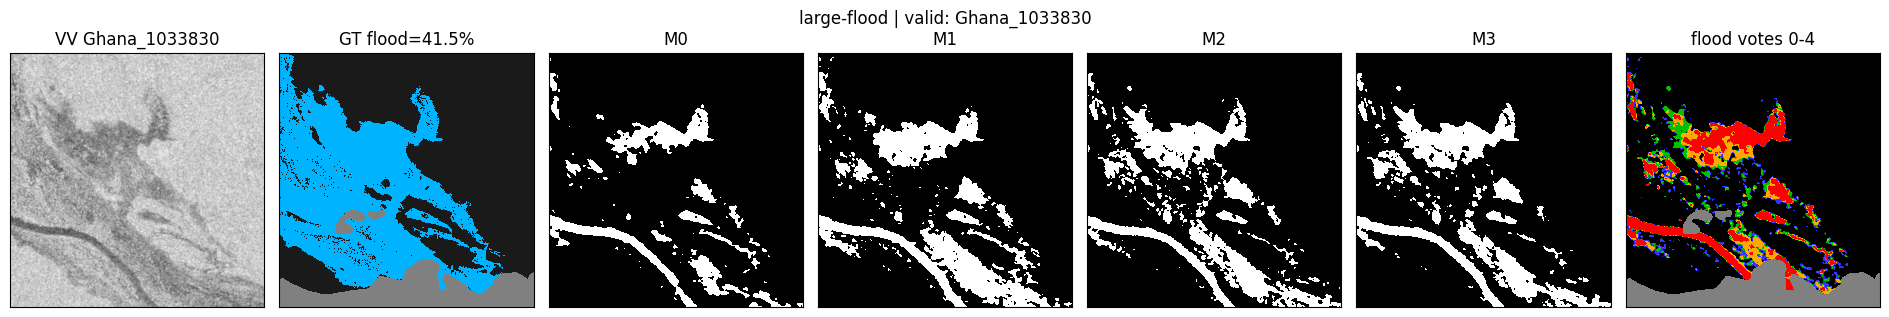

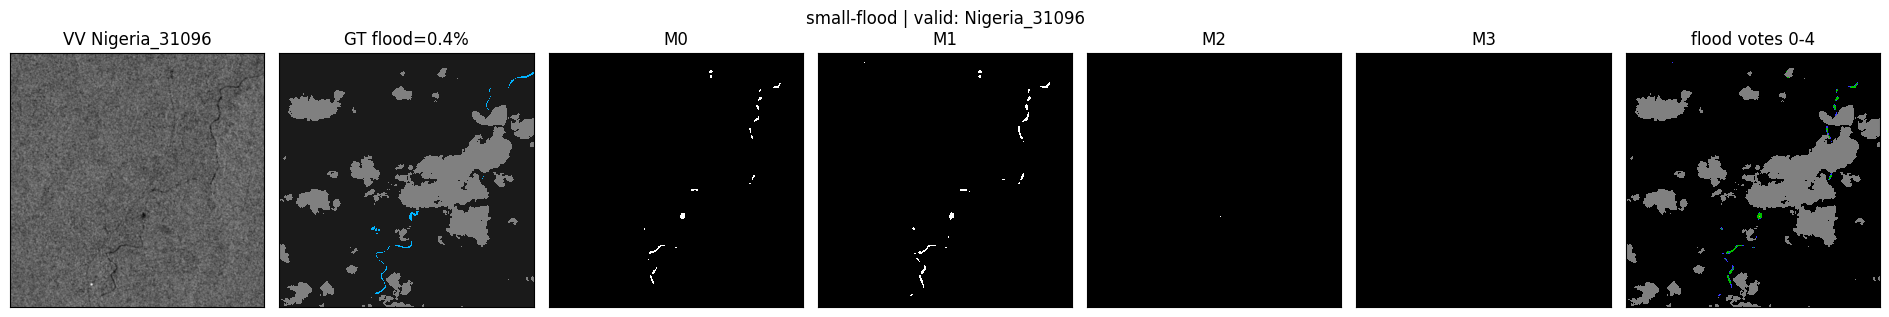

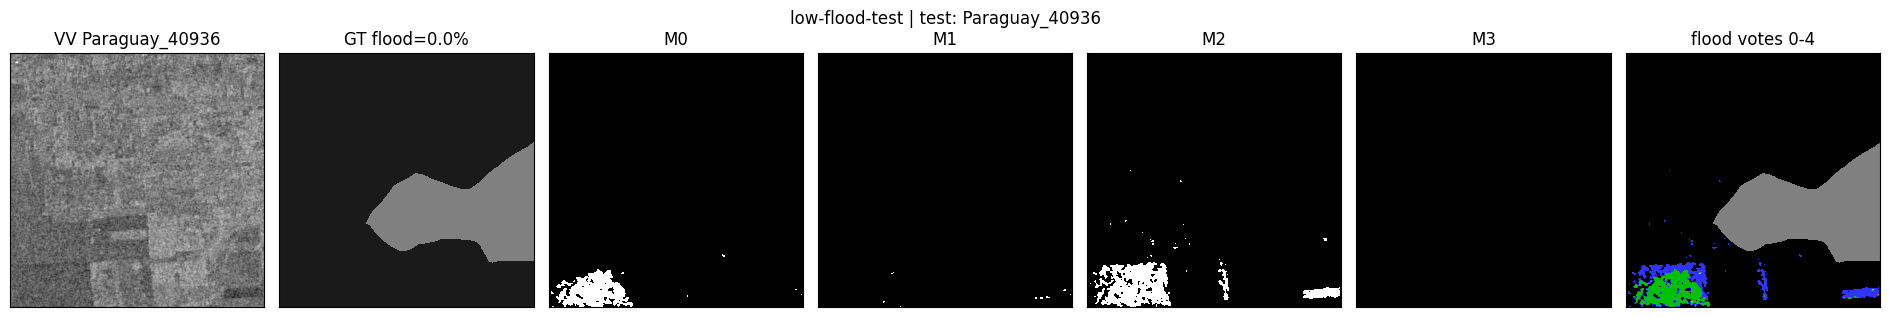

M0/M1/M2/M3 panels above (grey=invalid).


In [20]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
mp = pd.read_csv(PROCESSED_ROOT / "metadata.csv")
def _shown(split, idxs):
    ok = mp[(mp["split"] == split) & (mp["valid_frac"] > 0)].sort_values("chip_id")["chip_id"].tolist()
    return [(split, ok[i]) for i in idxs]
pool = _shown("valid", (0, 89 // 3, 2 * 89 // 3)) + _shown("test", (0, 89 // 2))
info = []
for split, stem in pool:
    raw = np.load(PROCESSED_ROOT / split / (stem + ".npz"), allow_pickle=True)
    y = raw["y"].astype(np.float32); m = raw["valid_mask"].astype(bool)
    info.append((split, stem, float((y[m] == 1).mean()) if m.any() else -1))
    del raw, y, m
info.sort(key=lambda t: t[2])
large = max(info, key=lambda t: t[2])
nonzero = [t for t in info if t[2] > 0]
small = min(nonzero, key=lambda t: t[2])
low = min([t for t in info if t[0] == "test"], key=lambda t: t[2])
roles = [("large-flood", large), ("small-flood", small), ("low-flood-test", low)]
print("roles:", [(r, s, c, f"{f:.2%}") for r, (s, c, f) in roles])
nets = {}
for tag, pth, ic in [("M0", MODEL_DIR / "nb04_s1_unet_best.pt", 2), ("M1", MODEL_DIR / "nb06_m1_s1_dem_best.pt", 3),
                     ("M2", MODEL_DIR / "nb06_m2_s1_rain_best.pt", 5), ("M3", MODEL_DIR / "nb05_multimodal_unet_best.pt", 6)]:
    nt = UNet(ic, BASE_CH).to(DEVICE).eval()
    nt.load_state_dict(torch.load(pth, map_location=DEVICE, weights_only=False)["state_dict"])
    nets[tag] = nt
mn = np.array(st["mean"], dtype=np.float32).reshape(-1, 1, 1); sd = np.array(st["std"], dtype=np.float32).reshape(-1, 1, 1)
chidx = {"M0": [0, 1], "M1": [0, 1, 2], "M2": [0, 1, 3, 4, 5], "M3": [0, 1, 2, 3, 4, 5]}
vote_cmap = ListedColormap(["#000000", "#3333ff", "#00c000", "#ffaa00", "#ff0000", "#808080"])
for role, (split, stem, ff) in roles:
    raw = np.load(PROCESSED_ROOT / split / (stem + ".npz"), allow_pickle=True)
    xn = (raw["X"].astype(np.float32) - mn) / sd
    bins = {}
    with torch.no_grad(), torch.amp.autocast("cuda", enabled=USE_AMP):
        for tag, nt in nets.items():
            bins[tag] = (torch.sigmoid(nt(torch.from_numpy(xn[chidx[tag]]).unsqueeze(0).to(DEVICE)))[0, 0].cpu().numpy() >= THR).astype(np.uint8)
    y = raw["y"].astype(np.float32); m = raw["valid_mask"].astype(bool)
    vote = (bins["M0"] + bins["M1"] + bins["M2"] + bins["M3"]).astype(np.uint8)
    vote = np.where(m, vote, 5)
    fig, ax = plt.subplots(1, 7, figsize=(19, 3.2))
    ax[0].imshow(raw["X"][0], cmap="gray"); ax[0].set_title(f"VV {stem}")
    ax[1].imshow(np.where(m, y, -1), cmap=ListedColormap(["#808080","#1a1a1a","#00b3ff"]), vmin=-1, vmax=1, interpolation="nearest")
    ax[1].set_title(f"GT flood={ff:.1%}")
    for j, tag in enumerate(("M0", "M1", "M2", "M3")):
        ax[2 + j].imshow(bins[tag], cmap="gray", vmin=0, vmax=1, interpolation="nearest"); ax[2 + j].set_title(tag)
    ax[6].imshow(vote, cmap=vote_cmap, vmin=0, vmax=5, interpolation="nearest"); ax[6].set_title("flood votes 0-4")
    for a in ax: a.set_xticks([]); a.set_yticks([])
    fig.suptitle(f"{role} | {split}: {stem}")
    fig.tight_layout(); plt.show()
    del raw, xn, y, m, bins, vote
print("M0/M1/M2/M3 panels above (grey=invalid).")


## 21. Final interpretation (evidence-based, single-seed caution)
IoU/F1 primary; precision/recall diagnostic; |ΔIoU|≤0.005 ≈ run variation.

In [21]:
order = sorted(("M1", "M2", "M3"), key=lambda t: master[t]["test"]["iou"], reverse=True)
print("test-IoU ranking:", [(t, round(master[t]['test']['iou'], 4)) for t in ['M0'] + order])
big = max(abs(master[t]["test"]["iou"] - base["iou"]) for t in ("M1", "M2", "M3"))
print(f"max |dIoU| vs M0: {big:.4f}")
if big <= 0.005:
    print("INTERPRETATION: no configuration shows an IoU effect beyond single-run variation - environmental modalities show no clear added value in this early-fusion UNet-32 setup.")
else:
    print("INTERPRETATION: at least one configuration moves IoU beyond the variation band - see table; still single-seed, so 'suggests', not 'proves'.")
print("Caveats: single seed; coarse IMERG; DEM may matter at other capacities/operating points; Bolivia generalization (NB07) may differ.")


test-IoU ranking: [('M0', 0.6684), ('M1', 0.6699), ('M3', 0.6639), ('M2', 0.639)]
max |dIoU| vs M0: 0.0294
INTERPRETATION: at least one configuration moves IoU beyond the variation band - see table; still single-seed, so 'suggests', not 'proves'.
Caveats: single seed; coarse IMERG; DEM may matter at other capacities/operating points; Bolivia generalization (NB07) may differ.


## 22. Context update

In [22]:
import datetime, re
now = datetime.datetime.now(datetime.timezone.utc).strftime("%Y-%m-%d %H:%M UTC")
m1t, m2t = master["M1"]["test"], master["M2"]["test"]
entry = (f"\n## {now} - NB06_Controlled_Ablations COMPLETE\n"
         f"- Shared protocol, only first-conv differs (params M0 7,762,753 / M1 7,763,041 / M2 7,763,617 / M3 7,763,905)\n"
         f"- M1 S1+DEM: {m1['minutes']} min best ep {m1['best_epoch']} val IoU={m1['val']['iou']:.4f}; TEST IoU={m1t['iou']:.4f} F1={m1t['f1']:.4f} (d={m1t['iou']-base['iou']:+.4f} vs M0)\n"
         f"- M2 S1+Rain: {m2['minutes']} min best ep {m2['best_epoch']} val IoU={m2['val']['iou']:.4f}; TEST IoU={m2t['iou']:.4f} F1={m2t['f1']:.4f} (d={m2t['iou']-base['iou']:+.4f} vs M0)\n"
         f"- M0 locked 0.6684 / M3 locked 0.6639 cited, protocol-compatibility verified, not retrained\n"
         f"- Gates PASS; Bolivia untouched; 6 zero-valid chips retained. NB06 safe to lock; next NB07 Bolivia.\n")
(CTX / "CHANGELOG.md").write_text((CTX / "CHANGELOG.md").read_text(encoding="utf-8") + entry, encoding="utf-8")
ps = CTX / "PROJECT_STATE.md"
t = ps.read_text(encoding="utf-8")
t = re.sub(r"^\*\*Last updated:\*\*.*$", f"**Last updated:** {now} (NB06 complete: yes)", t, count=1, flags=re.M)
t += f"\n\n## NB06 result ({now})\n- M1 test IoU={m1t['iou']:.4f} (d={m1t['iou']-base['iou']:+.4f}); M2 test IoU={m2t['iou']:.4f} (d={m2t['iou']-base['iou']:+.4f}); M0 0.6684 / M3 0.6639 locked.\n"
ps.write_text(t, encoding="utf-8")
dc = CTX / "DECISIONS.md"
t = dc.read_text(encoding="utf-8")
t = re.sub(r"^\*\*Last updated:\*\*.*$", f"**Last updated:** {now} (D14 ablation)", t, count=1, flags=re.M)
t += "\n## D14 - NB06 ablation verdict (" + now + ")\nShared-protocol M0/M1/M2/M3; M0/M3 locked-not-retrained; single-seed suggestive language only.\n"
dc.write_text(t, encoding="utf-8")
nx = CTX / "NEXT_STEPS.md"
t = nx.read_text(encoding="utf-8")
t = re.sub(r"^\*\*Last updated:\*\*.*$", f"**Last updated:** {now}", t, count=1, flags=re.M)
t += f"\n\n## Update ({now})\n- NB06 COMPLETE. Next: NB07 Bolivia geographic generalization.\n"
nx.write_text(t, encoding="utf-8")
print(entry)
print("Context files updated:", now)



## 2026-10-08 05:22 UTC - NB06_Controlled_Ablations COMPLETE
- Shared protocol, only first-conv differs (params M0 7,762,753 / M1 7,763,041 / M2 7,763,617 / M3 7,763,905)
- M1 S1+DEM: 14.83 min best ep 26 val IoU=0.6387; TEST IoU=0.6699 F1=0.8023 (d=+0.0015 vs M0)
- M2 S1+Rain: 8.24 min best ep 11 val IoU=0.6123; TEST IoU=0.6390 F1=0.7798 (d=-0.0294 vs M0)
- M0 locked 0.6684 / M3 locked 0.6639 cited, protocol-compatibility verified, not retrained
- Gates PASS; Bolivia untouched; 6 zero-valid chips retained. NB06 safe to lock; next NB07 Bolivia.

Context files updated: 2026-10-08 05:22 UTC
